<a href="https://colab.research.google.com/github/ricvazquez/ColabFiles/blob/main/EDA_Equipo5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis exploratorio de los datos (EDA)
## Caso: Indice de corrupcion percibida por pais del 2012 al 2025

**Integrantes**


*   Ricardo Vazquez 273509
*   Valeria Rodriguez Villezcas 271775
*   Rubén A. Uribe 271774


**Fecha:** 6 de Octubre del 2026

**Version de python:** 3.13.16



| Integrantes | Responsabilidad Principal |
| --- | --- |
| Ricardo Vazquez | Elaboracion del EDA |
| Ruben Uribe | Elaboracion de Reporte Final |
| Valeria Rodriguez | Elaboracion de la presentacion |


In [ ]:
## Imprimimos la version de Python para estar seguros
import sys

print(sys.version)

3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]


### Fuente

**Fuente:** Transparency International

**URL:** https://data.humdata.org/dataset/global-corruption-perceptions-index

**Licencia:** Creative Commons Attribution International (CC BY)

**Términos de uso:** Público


### Contexto del dominio

En este contenido podemos ver la representacion de la evaluacion de 183 paises, en el mundo dentro del **índice de percepcion de la corrupción**, en el cual se incluye informacion como la region(region), abreviacion de cada pais(iso3), su puntuacion(score), posición en el ranking (rank), numero de fuentes utilizadas (sources), el error estandar (standardError), y los limites del intervalo de confianza (lowerCi y upperCi). Este indice refleja la percepcion de fuentes confiables y representantes del sector empresarial, sobre la corrupcion en el sector publico, por lo que el analisis pudiera ser de ayuda para gobiernos, organizaciones internacionales, instituciones academicas, y empresas privadas que esten interesadas en buscar nuevos paises para invertir.

# Preguntas


*   ¿Cómo se han comportado los países de Norteamérica en el ranking?
*   ¿Cómo se ve la evolución en el ranking de México si lo comparamos contra el de Sudamérica?
*   Podemos decir que la distribución del “score” es simétrica o asimétrica?
*   ¿Cambió la percepción de corrupción en los países directamente involucrados en la guerra entre Rusia y Ucrania a partir de 2022, y ese cambio fue distinto al de Europa occidental/Unión Europea?



# Variable objetivo candidata

Para este punto tenemos dos, tanto **score** como **rank** ambas son de clasificacion

# Descripción de los datos

###**Unidad de observacion**

Una fila representa el resultado del indice de corrupcion percibida por país durante un año en especifico

###**Numero de registros**

El dataset contiene **2,494 registros** y **10 columnas**

###**Diccionario de datos**

|Nombre|tipo|Significado|Unidades|
|---|---|---|---|
|Country|Object/String|Nombre de cada país|texto|
|iso3|Object/String|Abreviacion de cada pais|texto|
|region|Object/String|Region o continente donde se ubica el pais|texto|
|year|Fecha/int|Año en la que se realizo la evaluacion|Fecha|
|score|int|puntuacion del indice del CPI por país| Escala 0-100|
|rank|int| Posicion de cada pais en el ranking segun su puntuacion|Lugar/Posicion|
|sources|int|Numero de fuentes consultadas para decidir la puntuacion ese año| numerico|
|standardError|float| Error estandar asociado a la estimacion del score|Puntos del CPI|
|lowerCi|int|Limite inferior del intervalo de confianza de la puntuacion|Puntos del CPI|
|upperCi|int| Limite superior del intervalo de confianza de la puntaucion|Puntos del CPI|


In [ ]:
# Primero Hacemos los imports de las librerias
import pandas as pd
import requests
from io import StringIO

# Nos traemos el csv con los datos que nos da la pagina
metadata = requests.get(
    "https://data.humdata.org/api/3/action/package_show",
    params={"id": "global-corruption-perceptions-index"}
).json()["result"]


recursog = next(
    recurso
    for recurso in metadata["resources"]
    if recurso["name"] == "global_cpi_all.csv"
)

url = recursog.get("download_url", recursog["url"])

respuesta = requests.get(url)
respuesta.raise_for_status()

df_global = pd.read_csv(StringIO(respuesta.text))

# Data Profiling

In [ ]:
##Sacamos cuantas filas y registrso tiene el dataset
print("Numero de filas: ", df_global.shape[0])
print("Numero de columnas: ", df_global.shape[1])

Numero de filas:  2494
Numero de columnas:  10


In [ ]:

# Hacemos un rapido resumen de lo que contiene del dataset para ver las columnas
# el tipo de dato por columna
# Si la columna tiene valores nulos
# Porcentaje de valores nulos
# Cuantos valores unicos existen por columna
resumen = pd.DataFrame({
    "variable": df_global.columns,
    "tipo": df_global.dtypes.astype(str),
    "valores_nulos": df_global.isna().sum().values,
    "Porcentaje de nulos": (df_global.isna().sum().values / df_global.shape[0]) * 100,
    "valores_unicos": df_global.nunique().values
})

resumen

,variable,tipo,valores_nulos,Porcentaje de nulos,valores_unicos
country,country,object,0,0.0,183
iso3,iso3,object,0,0.0,183
region,region,object,0,0.0,6
year,year,int64,0,0.0,14
score,score,int64,0,0.0,85
rank,rank,int64,0,0.0,181
sources,sources,int64,0,0.0,8
standardError,standardError,float64,0,0.0,560
lowerCi,lowerCi,int64,0,0.0,87
upperCi,upperCi,int64,0,0.0,85


In [ ]:
# Aparentemente no hay datos nulos
# Vamos a revisar si hay algun duplicado, que no deba estar ahi
filasdubs = df_global.duplicated().sum()
print("Filas identicas:",filasdubs)
# El que se me ocurre es que un pais tenga dos registros en un año, lo cual seria un error del dataset
dubs = df_global.duplicated(subset = ["country","year"]).sum()
print("Filas que hubieras podido ser error:",dubs)
# Por lo visto no hay duplicados erroneos

Filas identicas: 0
Filas que hubieras podido ser error: 0


In [ ]:
# Ahora revisamos la cardinalidad
card = df_global.nunique(dropna=False).sort_values()
# Por los tipos de datos, podemos saber de antemano que al menos 2 columnas deben tener el mismo valor
#country-iso3 ya que donde se repita el pais, se debe repetir la abreviacion
print(card)

region             6
sources            8
year              14
score             85
upperCi           85
lowerCi           87
rank             181
iso3             183
country          183
standardError    560
dtype: int64


In [ ]:
# Rangos validos
df_global.describe().T
# Como podemos ver, ninguna columna pareciera tener datos atipicos
# Esto es porque al ser un fuente formal, el dataset parece ya procesado
# Podemos hablar de una alta calidad en los datos

,count,mean,std,min,25%,50%,75%,max
year,2494.0,2018.552125,4.030307,2012.00,2015.00,2019.0,2022.0000,2025.00
score,2494.0,42.985164,19.208177,8.00,29.00,38.0,56.0000,92.00
rank,2494.0,88.208901,51.137875,1.00,44.00,87.0,131.0000,181.00
sources,2494.0,6.783480,1.837467,3.00,6.00,7.0,8.0000,10.00
standardError,2494.0,2.780245,1.521753,0.37,1.75,2.4,3.3475,12.81
lowerCi,2494.0,38.424218,19.390856,2.00,24.00,34.0,51.0000,89.00
upperCi,2494.0,47.544507,19.357247,11.00,33.00,43.0,62.0000,95.00


# Limpieza y transformacion

Al no tener nulos o registros duplicados, este dataset no requiere una limpieza, lo que si podemos hacer es transformar la columna de region a categoria, ya que posee pocos registros duplicados, las columnas de year y source a pesar de tener pocos valores unicos, no son candidatas a transformar a categorias ya que seran importantes para revisar las tendencias centrales, las que si podemos usar son country e iso3

In [ ]:
# Revisamos cuanta memoria ocupan las columnas antes hacer el cambio
memoria_r = df_global["region"].memory_usage(deep=True)
memoria_c = df_global["country"].memory_usage(deep=True)
memoria_i = df_global["iso3"].memory_usage(deep=True)

print("Memoria utilizada en region",memoria_r)
print("Memoria utilizada en country",memoria_c)
print("Memoria utilizada en iso3",memoria_i)

# Hacemos la transformacion
df_global["region"] = df_global["region"].astype("category")
df_global['country'] = df_global['country'].astype('category')
df_global['iso3'] = df_global['iso3'].astype('category')

# Revisamos cuanta memoria ahorramos con el cambio
print("Memoria ahorrada en region",memoria_r - df_global["region"].memory_usage(deep=True))
print("Memoria ahorrada en country",memoria_c - df_global["country"].memory_usage(deep=True))
print("Memoria ahorrada en iso3",memoria_i - df_global["iso3"].memory_usage(deep=True))


Memoria utilizada en region 130520
Memoria utilizada en country 143910
Memoria utilizada en iso3 129820
Memoria ahorrada en region 127408
Memoria ahorrada en country 124068
Memoria ahorrada en iso3 111016


# Estadistica Descriptiva


*   Tendencia central
*   Dispersion
*   Forma



In [ ]:
# Hacemos un arreglo con las principales columnas (score, rank, sources y year)
cols = ["score","rank","sources","year"]

# Vemos el describe solo de esas columnas, para ver las estadisticas
est = df_global[cols].describe().T
est

,count,mean,std,min,25%,50%,75%,max
score,2494.0,42.985164,19.208177,8.0,29.0,38.0,56.0,92.0
rank,2494.0,88.208901,51.137875,1.0,44.0,87.0,131.0,181.0
sources,2494.0,6.783480,1.837467,3.0,6.0,7.0,8.0,10.0
year,2494.0,2018.552125,4.030307,2012.0,2015.0,2019.0,2022.0,2025.0


In [ ]:
# Ahora revisamos la tendencia (Media, moda y mediana) de nuestros datos principales
tens = pd.DataFrame({
    "media": df_global[cols].mean(),
    "moda": df_global[cols].mode().iloc[0],
    "mediana": df_global[cols].median()
})
tens

,media,moda,mediana
score,42.985164,36,38.0
rank,88.208901,130,87.0
sources,6.783480,8,7.0
year,2018.552125,2025,2019.0


Podemos decir que en todas las columnas la moda y la mediana son muy parecidas, aunque siendo la media un poco mayor a la mediana, pudier haber cierto sesgo positivo

In [ ]:
# Dispersion
#Vamos a ver como se porta la desviacion estandar, la varianza, el minimo, el maximo y el rango de nuestras columnas principales
disp = pd.DataFrame({
    "desviacion estandar": df_global[cols].std(),
    "varianza": df_global[cols].var(),
    "minimo": df_global[cols].min(),
    "maximo": df_global[cols].max(),
    "rango": df_global[cols].max() - df_global[cols].min()
})
disp

,desviacion estandar,varianza,minimo,maximo,rango
score,19.208177,368.954052,8,92,84
rank,51.137875,2615.082295,1,181,180
sources,1.837467,3.376285,3,10,7
year,4.030307,16.243371,2012,2025,13


In [ ]:
# Forma de la distribucion
# Ahora calculamos la asimetria y la curtosis de nuestras columnas principales
dist = pd.DataFrame({
    "asimetria": df_global[cols].skew(),
    "curtosis": df_global[cols].kurtosis()
})
dist

,asimetria,curtosis
score,0.612879,-0.445771
rank,0.027514,-1.176881
sources,-0.437778,-0.561240
year,-0.019336,-1.206462


Como lo dijimos con la media y mediana, el dataset pudiera tener cierto sesgo positivo con la asimetria ligeramente mayor a cero

###Subgrupos relevantes para las preguntas

Empezaremos los subgrupos empezando por region, dado que no se especifica que region es cada nomenclatura, aqui dejamos la tabla para entender mejor los datos

|Region|Continente|
|---|---|
|Ame|America|
|AP| Asia-Pacifico|
|ECA|Europa and Central Asia|
|Mena|Oriente medio y Norte de Africa|
|SSA|Africa Subsahariana|
|WE/EU|Union Europea|

In [ ]:
# Reducimos la lista de columnas a rank y score ya que son las que mas pudieran variar por region
colsxreg = ["score","rank"]
# Agrupamos por region
estxregion = df_global.groupby("region")[colsxreg].describe().T
estxregion

/tmp/ipykernel_1897/2272110367.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  estxregion = df_global.groupby("region")[colsxreg].describe().T


region              AME          AP         ECA        MENA         SSA  \
score count  443.000000  420.000000  266.000000  252.000000  679.000000   
      mean    43.453725   44.178571   34.383459   38.742063   32.365243   
      std     17.162373   20.540757    9.030115   16.433160   12.477911   
      min     10.000000    8.000000   17.000000   12.000000    8.000000   
      25%     31.000000   30.000000   28.000000   25.000000   24.000000   
      50%     38.000000   38.000000   35.000000   39.000000   30.000000   
      75%     58.000000   61.000000   40.000000   49.000000   40.000000   
      max     84.000000   91.000000   58.000000   71.000000   72.000000   
rank  count  443.000000  420.000000  266.000000  252.000000  679.000000   
      mean    85.203160   86.114286  108.033835   96.706349  116.923417   
      std     46.911241   51.642763   33.634590   50.571486   41.623293   
      min      8.000000    1.000000   41.000000   21.000000   18.000000   
      25%     41.000000   35.000000   80.250000   56.000000   83.000000   
      50%     87.000000   90.500000  106.500000   86.500000  124.000000   
      75%    123.000000  126.250000  133.000000  149.000000  152.000000   
      max    180.000000  177.000000  170.000000  178.000000  181.000000   

region            WE/EU  
score count  434.000000  
      mean    65.702765  
      std     14.607779  
      min     36.000000  
      25%     54.000000  
      50%     63.000000  
      75%     79.000000  
      max     92.000000  
rank  count  434.000000  
      mean    31.294931  
      std     22.471036  
      min      1.000000  
      25%     10.250000  
      50%     30.000000  
      75%     49.000000  
      max     94.000000

**Nota:** Se pudieran definir muchos datos interesantes con solo este describe, como que europa es un mundo diferente a los demas, o que aunque Africa sea un continente, al mostrar los datos separados, se puede ver que en ranking, africa de sur en promedio suele estar mas abajo que africa del norte y medio oriente

In [ ]:
# Quitamos los warnings
import warnings
warnings.filterwarnings("ignore")
# Hacemos el resumen por region
tensxregion ={
    "media": df_global.groupby("region")[colsxreg].mean(),
    "mediana": df_global.groupby("region")[colsxreg].median(),
    "moda": df_global.groupby("region")[colsxreg].agg(lambda x: x.value_counts().index[0])
}
tensxregion = pd.concat(tensxregion,axis=1)
tensxregion

media             mediana         moda     
            score        rank   score   rank score rank
region                                                 
AME     43.453725   85.203160    38.0   87.0    38   83
AP      44.178571   86.114286    38.0   90.5    38   18
ECA     34.383459  108.033835    35.0  106.5    36   91
MENA    38.742063   96.706349    39.0   86.5    13  178
SSA     32.365243  116.923417    30.0  124.0    26  130
WE/EU   65.702765   31.294931    63.0   30.0    56    1

In [ ]:
warnings.filterwarnings("ignore")
# Ahora traemos la desviacion, la varianza, el minimo, el maximo y el rango
dispxreg = {
    "desviacion estandar": df_global.groupby("region")[colsxreg].std(),
    "varianza": df_global.groupby("region")[colsxreg].var(),
    "minimo": df_global.groupby("region")[colsxreg].min(),
    "maximo": df_global.groupby("region")[colsxreg].max(),
    "rango": df_global.groupby("region")[colsxreg].max() - df_global.groupby("region")[colsxreg].min()
}

# Combinar todas las métricas horizontalmente
dispxreg = pd.concat(dispxreg, axis=1)
dispxreg

desviacion estandar               varianza              minimo       \
                     score       rank       score         rank  score rank   
region                                                                       
AME              17.162373  46.911241  294.547062  2200.664515     10    8   
AP               20.540757  51.642763  421.922690  2666.974974      8    1   
ECA               9.030115  33.634590   81.542971  1131.285643     17   41   
MENA             16.433160  50.571486  270.048742  2557.475179     12   21   
SSA              12.477911  41.623293  155.698259  1732.498551      8   18   
WE/EU            14.607779  22.471036  213.387198   504.947457     36    1   

       maximo      rango       
        score rank score rank  
region                         
AME        84  180    74  172  
AP         91  177    83  176  
ECA        58  170    41  129  
MENA       71  178    59  157  
SSA        72  181    64  163  
WE/EU      92   94    56   93

In [ ]:
# Revisamos la asimetria por region
distxreg = {
    "asimetria": df_global.groupby("region")[colsxreg].skew(),
}
distxreg = pd.concat(distxreg,axis=1)
distxreg

asimetria          
           score      rank
region                    
AME     0.462494  0.103930
AP      0.640532 -0.073899
ECA     0.181194  0.026947
MENA    0.157378  0.234010
SSA     0.646250 -0.443128
WE/EU   0.001108  0.398855

#EDA orientado a preguntas

Empecemos con la primera pregunta

**¿Cómo se han comportado los países de Norteamérica en el ranking?**

In [ ]:
# Seleccionamos los paises involucrados
norta= ["Mexico","Canada","United States of America"]
df_norta = df_global[df_global["country"].isin(norta)]
# Como Country es categorica, debemos eliminar los demas paises
df_norta['country'] = df_norta['country'].cat.remove_unused_categories()
print(df_norta.shape)
print(df_norta.head())

(42, 10)
                      country iso3 region  year  score  rank  sources  \
29                     Canada  CAN    AME  2025     75    16        8   
106                    Mexico  MEX    AME  2025     27   141        8   
173  United States of America  USA    AME  2025     64    29        9   
209                    Canada  CAN    AME  2024     75    15        8   
286                    Mexico  MEX    AME  2024     26   140        8   

     standardError  lowerCi  upperCi  
29            1.96       72       78  
106           1.49       25       29  
173           2.64       60       68  
209           1.95       72       78  
286           1.66       23       29  


In [ ]:
# Ahora revisamos la tendencia (Media, moda y mediana) de nuestros datos principales
# Revisando unicamente el rank y el score
# print(df_norta['country'].unique())
colsna = ["score","rank"]
warnings.filterwarnings("ignore")
tensnorta ={
    "media": df_norta.groupby("country")[colsna].mean(),
    "mediana": df_norta.groupby("country")[colsna].median(),
    "moda": df_norta.groupby("country")[colsna].agg(lambda x: x.value_counts().index[0])
}
tensnorta = pd.concat(tensnorta,axis=1)
tensnorta

media             mediana         moda     
                              score        rank   score   rank score rank
country                                                                  
Canada                    78.714286   11.214286    79.0   10.5    81    9
Mexico                    30.500000  123.714286    31.0  125.0    31  124
United States of America  70.428571   21.928571    70.0   22.5    69   24

Con solo sacar media, mediana y moda, ya nos podemos dar una idea de la gran diferencia entre puestos en el ranking y score entre USA,Canada y Mexico

In [ ]:
warnings.filterwarnings("ignore")
# Ahora traemos la desviacion, la varianza, el minimo, el maximo y el rango de norte america
dispnorta = {
    "desviacion estandar": df_norta.groupby("country")[colsna].std(),
    "varianza": df_norta.groupby("country")[colsna].var(),
    "minimo": df_norta.groupby("country")[colsna].min(),
    "maximo": df_norta.groupby("country")[colsna].max(),
    "rango": df_norta.groupby("country")[colsna].max() - df_norta.groupby("country")[colsna].min()
}

dispnorta = pd.concat(dispnorta, axis=1)
dispnorta

desviacion estandar              varianza  \
                                       score       rank      score   
country                                                              
Canada                              3.604027   2.516975  12.989011   
Mexico                              2.623855  13.011407   6.884615   
United States of America            3.837353   4.462912  14.725275   

                                     minimo      maximo      rango       
                                rank  score rank  score rank score rank  
country                                                                  
Canada                      6.335165     74    8     84   16    10    8  
Mexico                    169.296703     26  103     35  141     9   38  
United States of America   19.917582     64   16     76   29    12   13

Con el rango podemos ver como Mexico es el que mas cambios tuvo a lo largo del tiempo, Canada fue el mas estable y USA tuvo sus altibajos cayendo casi fuera del top 30 en el ranking

In [ ]:
# Traemos los import para hacer graficas
import matplotlib.pyplot as plt
import seaborn as sns

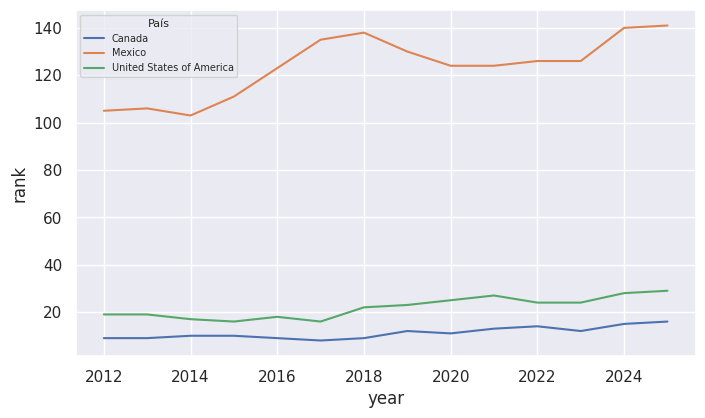

In [ ]:
# Graficamos para ver como se ha comportado el ranking en norte america a traves del tiempo (2012-2015)
sns.set_theme()
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=df_norta,x="year",y="rank",hue="country",ax=ax)
ax.legend(title="País",fontsize=7,title_fontsize=8)
plt.show()


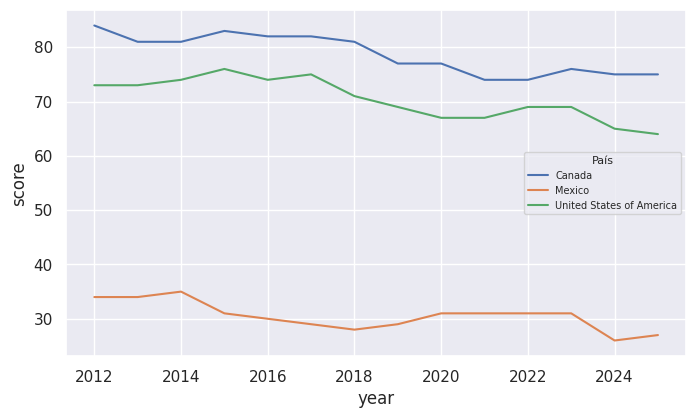

In [ ]:
# Hacemos otra grafica ara ver como se comportado el score
sns.set_theme()
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=df_norta,x="year",y="score",hue="country",ax=ax)
ax.legend(title="País",fontsize=7,title_fontsize=8)
plt.show()

**Conclusion:** Como podemos ver, tristemente Mexico no esta ni cerca de los indices tan positivos que manejan USA y Canada en cuanto a corrupcion

## Pregunta 2
**¿Cómo se ve la evolución en el ranking de México si lo comparamos contra el de Sudamérica?**

In [ ]:
##Creamos el dataset donde filtremos solo Mexico los paises de sudamerica
suda= ["Mexico","Colombia","Argentina", "Bolivia", "Brazil", "Ecuador","Paraguay","Peru","Uruguay","Venezuela"]
df_suda = df_global[df_global["country"].isin(suda)]
df_suda['country'] = df_suda['country'].cat.remove_unused_categories()
print(df_suda.shape)
print(df_suda.head())


(140, 10)
      country iso3 region  year  score  rank  sources  standardError  lowerCi  \
4   Argentina  ARG    AME  2025     36   104        8           2.18       32   
18    Bolivia  BOL    AME  2025     28   136        7           3.00       23   
21     Brazil  BRA    AME  2025     35   107        8           2.76       30   
34   Colombia  COL    AME  2025     37    99        8           2.22       33   
48    Ecuador  ECU    AME  2025     33   116        7           1.87       30   

    upperCi  
4        40  
18       33  
21       40  
34       41  
48       36  


In [ ]:
## Sacamos la media, la mediana y la moda pero de los paises de sudamerica
colssa = ["score","rank"]
warnings.filterwarnings("ignore")

tensuda ={
    "media": df_suda.groupby("country")[colssa].mean(),
    "mediana": df_suda.groupby("country")[colssa].median(),
    "moda": df_suda.groupby("country")[colssa].agg(lambda x: x.value_counts().index[0])
}
tensuda = pd.concat(tensuda,axis=1)
tensuda

media             mediana         moda     
               score        rank   score   rank score rank
country                                                   
Argentina  37.357143   94.357143    37.0   97.0    36  106
Bolivia    31.428571  119.428571    31.0  123.5    31  133
Brazil     38.000000   91.000000    38.0   95.0    38  107
Colombia   37.571429   92.428571    37.0   93.0    37   94
Ecuador    34.071429  109.285714    33.5  112.0    32  116
Mexico     30.500000  123.714286    31.0  125.0    31  124
Paraguay   27.000000  138.857143    28.0  137.0    24  150
Peru       35.500000  101.428571    36.0  101.0    36  101
Uruguay    72.428571   19.142857    73.0   20.5    73   21
Venezuela  15.714286  170.357143    16.5  171.0    10  177

Con las puras medias, medianas y modas, ya se ve un poco mas parejo a la anterior comparacion

In [ ]:
# Ahora veremos como se comporta la dispersion de los datos, para ver si seguimos notando cierta paridad
dispsur = {
    "desviacion estandar": df_suda.groupby("country")[colssa].std(),
    "varianza": df_suda.groupby("country")[colssa].var(),
    "minimo": df_suda.groupby("country")[colssa].min(),
    "maximo": df_suda.groupby("country")[colssa].max(),
    "rango": df_suda.groupby("country")[colssa].max() - df_suda.groupby("country")[colsna].min()
}
dispsur = pd.concat(dispsur, axis=1)
dispsur

desviacion estandar              varianza             minimo       \
                        score       rank      score        rank  score rank   
country                                                                       
Argentina            3.410552  11.984651  11.631868  143.631868     32   66   
Bolivia              2.408775  12.906255   5.802198  166.571429     28   98   
Brazil               3.012793  14.853127   9.076923  220.615385     34   69   
Colombia             1.342460   4.602914   1.802198   21.186813     36   83   
Ecuador              2.432608   9.619120   5.917582   92.527473     31   92   
Mexico               2.623855  13.011407   6.884615  169.296703     26  103   
Paraguay             2.320477   9.313821   5.384615   86.747253     24  123   
Peru                 2.564551  15.425824   6.576923  237.956044     30   83   
Uruguay              1.696797   3.134354   2.879121    9.824176     70   13   
Venezuela            3.196839   7.468983  10.219780   55.785714     10  158   

          maximo      rango       
           score rank score rank  
country                           
Argentina     45  107    13   41  
Bolivia       35  136     7   38  
Brazil        43  107     9   38  
Colombia      40   99     4   16  
Ecuador       39  121     8   29  
Mexico        35  141     9   38  
Paraguay      30  150     6   27  
Peru          38  130     8   47  
Uruguay       76   23     6   10  
Venezuela     20  180    10   22

Podemos ver como Mexico es de los que mas ha variado en el ranking en Sudamerica

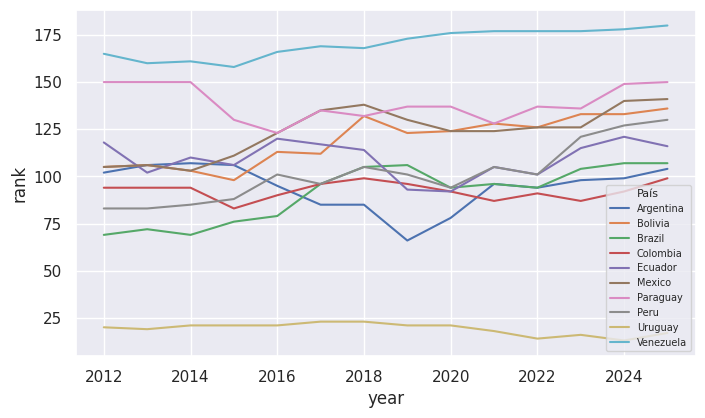

In [ ]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=df_suda,x="year",y="rank",hue="country",ax=ax)
ax.legend(title="País",fontsize=7,title_fontsize=8)
plt.show()

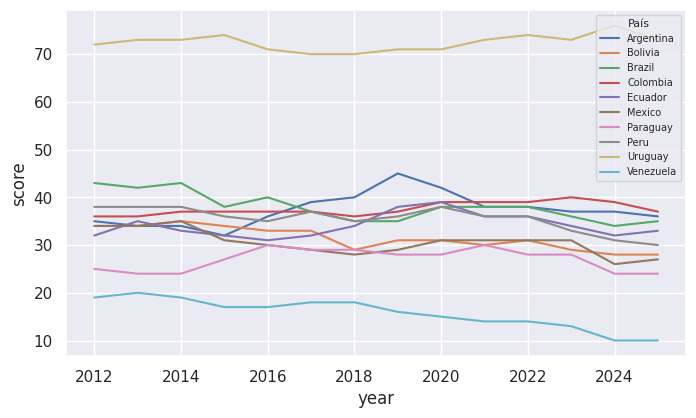

In [ ]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=df_suda,x="year",y="score",hue="country",ax=ax)
ax.legend(title="País",fontsize=7,title_fontsize=8)
plt.show()

**Conclusion:** Con las graficas podemos ver como Mexico aunque pudiera verse mas parejo, nos sigue situando el tercer peor pais en cuanto a la percepcion de corrupcion a comparacion de sudamerica, y como parece que Uruguay tiene metricas mas parecidas a Norte America, teniendo buenos indices de percepcion de corrupcion

##Pregunta 3
**¿Cambió la percepción de corrupción en los países directamente involucrados en la guerra entre Rusia y Ucrania a partir de 2022, y ese cambio fue distinto al de Europa occidental/Unión Europea?**

In [ ]:
#Seleccionamos los paises correspondientes
war= ["Russia","Ukraine"]
df_war = df_global[df_global["country"].isin(war)]
df_war['country'] = df_war['country'].cat.remove_unused_categories()
print(df_war.shape)
print(df_war.head())


(28, 10)
     country iso3 region  year  score  rank  sources  standardError  lowerCi  \
134   Russia  RUS    ECA  2025     22   157        7           1.48       20   
170  Ukraine  UKR    ECA  2025     36   104        8           2.40       32   
314   Russia  RUS    ECA  2024     22   154        7           1.55       19   
350  Ukraine  UKR    ECA  2024     35   105        8           2.09       32   
494   Russia  RUS    ECA  2023     26   141        7           1.47       24   

     upperCi  
134       24  
170       40  
314       25  
350       38  
494       28  


In [ ]:
# Creamos un promedio de la region europea
# Utilizamos la region WE/UE. la agrupamos y de ahi utilizamos la mediana de rank y score
# Seleccionamos la mediana sobre la media, porque al tener un ligero sesgo positivo (media>mediana), queremos no sesgar el promedio hacia arriba
# Mejor tomamos el promedio de la mitad de los datos de la region
prom = (df_global[df_global['region']=="WE/EU"].groupby("year", as_index=False)[colssa].median().assign(country="PromEU"))
# prom["country"] = prom['country'].cat.remove_unused_categories()
print(prom.shape)
print(prom.head())
prom

(14, 4)
   year  score  rank country
0  2012   65.0  30.0  PromEU
1  2013   63.0  31.0  PromEU
2  2014   63.0  31.0  PromEU
3  2015   64.0  28.0  PromEU
4  2016   62.0  29.0  PromEU


,year,score,rank,country
0,2012,65.0,30.0,PromEU
1,2013,63.0,31.0,PromEU
2,2014,63.0,31.0,PromEU
3,2015,64.0,28.0,PromEU
4,2016,62.0,29.0,PromEU
5,2017,63.0,29.0,PromEU
6,2018,64.0,30.0,PromEU
7,2019,62.0,30.0,PromEU
8,2020,62.0,32.0,PromEU
9,2021,62.0,32.0,PromEU


In [ ]:
## Juntamos los dos datasets
df_war2 = pd.concat([df_war,prom],ignore_index=True)
# Ahora como solo nos it=nteresa los datos durante la guerra la cual empezo el 22 de Febrero del 2022
# Vamos a filtrar los años del 2020(Para tener un margen de comparacion) en adelante
df_war2 = df_war2[df_war2["year"]>=2020]
print(df_war2.shape)
print(df_war2.head(5))

(18, 10)
   country iso3 region  year  score   rank  sources  standardError  lowerCi  \
0   Russia  RUS    ECA  2025   22.0  157.0      7.0           1.48     20.0   
1  Ukraine  UKR    ECA  2025   36.0  104.0      8.0           2.40     32.0   
2   Russia  RUS    ECA  2024   22.0  154.0      7.0           1.55     19.0   
3  Ukraine  UKR    ECA  2024   35.0  105.0      8.0           2.09     32.0   
4   Russia  RUS    ECA  2023   26.0  141.0      7.0           1.47     24.0   

   upperCi  
0     24.0  
1     40.0  
2     25.0  
3     38.0  
4     28.0  


In [ ]:
## Ya con el dataset creado empezamos a hacer el analisis de los datos
warnings.filterwarnings("ignore")
wars ={
    "media": df_war2.groupby("country")[colssa].mean(),
    "mediana": df_war2.groupby("country")[colssa].median(),
    "moda": df_war2.groupby("country")[colssa].agg(lambda x: x.value_counts().index[0])
}
wars = pd.concat(wars,axis=1)
wars

media             mediana         moda       
             score        rank   score   rank score   rank
country                                                   
PromEU   62.500000   31.833333    62.0   32.0  62.0   32.0
Russia   26.166667  142.333333    27.0  139.0  22.0  157.0
Ukraine  34.166667  111.333333    34.0  110.5  36.0  104.0

In [ ]:
dispwar = {
    "desviacion estandar": df_war2.groupby("country")[colssa].std(),
    "varianza": df_war2.groupby("country")[colssa].var(),
    "minimo": df_war2.groupby("country")[colssa].min(),
    "maximo": df_war2.groupby("country")[colssa].max(),
    "rango": df_war2.groupby("country")[colssa].max() - df_war2.groupby("country")[colssa].min()
}

# Combinar todas las métricas horizontalmente
dispwar = pd.concat(dispwar, axis=1)
dispwar

desviacion estandar              varianza             minimo         \
                      score       rank      score        rank  score   rank   
country                                                                       
PromEU             1.378405   2.041241   1.900000    4.166667   61.0   28.0   
Russia             3.488075  10.948364  12.166667  119.866667   22.0  129.0   
Ukraine            1.722401   7.941452   2.966667   63.066667   32.0  104.0   

        maximo        rango        
         score   rank score  rank  
country                            
PromEU    65.0   34.0   4.0   6.0  
Russia    30.0  157.0   8.0  28.0  
Ukraine   36.0  122.0   4.0  18.0

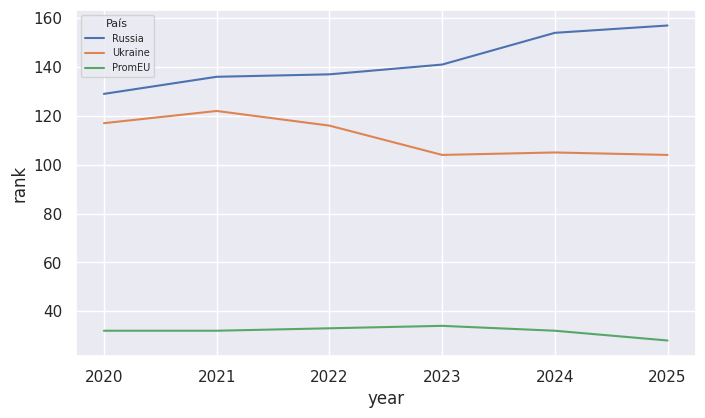

In [ ]:
# Revisamos visualmente los datos en el transcurso de los años
sns.set_theme()
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=df_war2,x="year",y="rank",hue="country",ax=ax)
ax.legend(title="País",fontsize=7,title_fontsize=8)
plt.show()

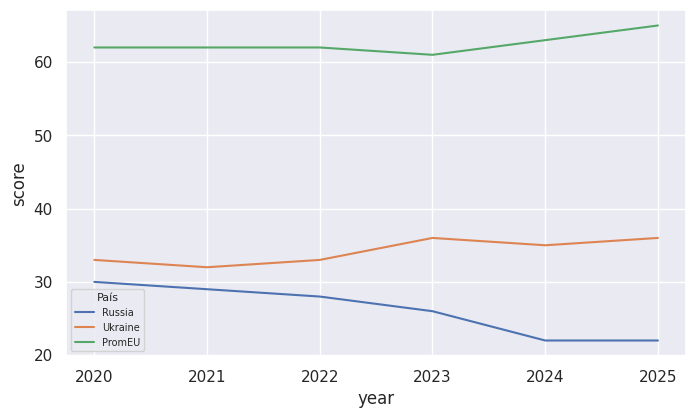

In [ ]:
sns.set_theme()
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=df_war2,x="year",y="score",hue="country",ax=ax)
ax.legend(title="País",fontsize=7,title_fontsize=8)
plt.show()

**Conclusion:** Ahora que visualizamos los datos podemos ver como en promedio europa en esa epoca aumento su indice de percepcion de corrupcion para bien, y el que mas se vio afectado fue Rusia, cayendo drasticamente del 2022 al 2024, a diferencia de Ucrania, el cual a pesar de estar en guerra, la gente cree que la corrupcion ha disminuido en su pais

# Hallazgos e investigacion
Retomando la investigacion podemos dar los siguientes hallazgos encontrados

| Pregunta | Respuesta | Evidencia (sección / gráfica) |
|---|---|---|
| P1 | Los tres países de Norteamérica perdieron posiciones en el ranking de percepción de corrupción entre 2012 y 2025 pero fue el que México se deterioró mucho más que Canadá y Estados Unidos. | [tablas de dispersión y gráficas de ranking y score] |
| P2 | México presenta una percepción de corrupción más desfavorable que la mayoría de los países sudamericanos analizados y una tendencia de deterioro en el ranking.| [tablas de tendencia central y gráficas de ranking y score] |
| P3 | Rusia y Ucrania presentaron trayectorias distintas en la percepción de corrupción a partir de 2022, mientras que Europa occidental y la Unión Europea mantuvieron resultados relativamente estables.|  tablas de dispersión y gráficas de ranking y score] |

### 8.2 Limitaciones y sesgos de los datos

- **Percepción no es igual a corrupción real:** el CPI resume opiniones de expertos y empresarios, lo cual no implica que realmente el país sea poco o muy corrupto
- **No todos los países aparecen todos los años:** 17 de los 183 países no aparecen los 14 años (68 registros menos que un panel completo) y el número de países evaluados va de 168 a 182 por año, sin embargo esto no afectó la información para responder a nuestras preguntas
- **Periodo y variables limitados:** los datos cubren 2012-2025 e incluyen pocas variables, por lo que se tiene que cruzar con otros datasets para ampliar el número de preguntas que se pueden responder
- **Sin subregiones:** la región `AME` agrupa todo el continente, por lo que Norteamérica y Sudamérica se definieron a mano dado que Norteamerica solo son 3 países, pero si se usara para otras regiones, seguramente se tendría que hacer una nueva columna y clasificarlos
- **Asociaciones sin causalidad directa:** los resultados de la guerra no permiten confirmar causalidad, solo se puede inferir un posible efecto; asimismo, la pandemia tuvo lugar casi al mismo tiempo y también pudo haber influido

## 9. Declaración de uso de IA y referencias

### 9.1 Declaración de uso de IA
| Herramienta | Para qué tarea se usó | Cómo se verificó el resultado |
|---|---|---|
| [No se utilizó IA] | NA| NA

### 9.2 Referencias
- https://data.humdata.org/dataset/global-corruption-perceptions-index
